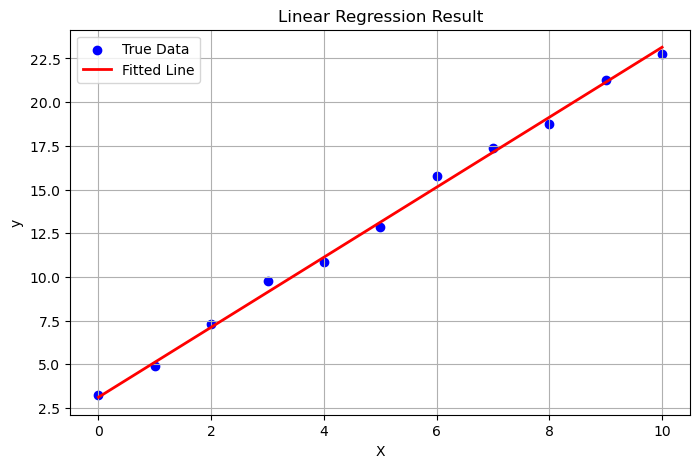

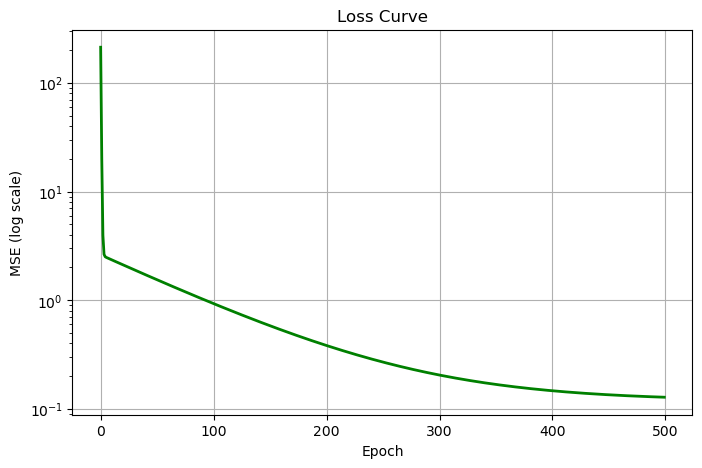

In [2]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42) #设置随机种子,保持每次生成随机数相同
X=np.linspace(0,10,11).reshape(-1,1) #任意行1列 0 1 2-10 11个
#linspace 均值分配
y=2*X+3+np.random.randn(11,1)*0.5#真实值为w=2,b=3。模型是为了学习w=2,b=3
#加入均值为0,标准差为0.5的高斯噪声,模拟真实数据的误差。后面random是噪声
w=np.array([[0.0]])
b=np.array([[0.0]]) #(1,1)

lr=0.01 #学习率:控制每次更新步长
epochs=500 #迭代次数
losses=[] #记录每一轮损失值

for i in range(epochs):
    y_pred=X@w+b
    #使用均方误差MSE计算损失
    loss=np.mean((y_pred-y)**2)
    losses.append(float(loss))
    #使用均方误差MSE,因为MSE是凸函数,有唯一的全局最小值;
    #其导数形式为线性,梯度计算方便；对异常值敏感,能推动模型快速修正
    
    #反向传播:计算梯度 dl/dw，dL/db 求导
    grad_w=(2/len(X))*(X.T@(y_pred-y))
    grad_b=(2/len(X))*np.sum(y_pred-y)
    #更新参数 反向更新参数
    w=w-lr*grad_w
    b=b-lr*grad_b
    #w和b从0开始向2x+3接近
# 绘制拟合结果
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', label='True Data')  # 画出真实数据点（蓝色散点）
plt.plot(X, X @ w + b, color='red', linewidth=2, label='Fitted Line')  # 画出模型拟合的直线（红色）
plt.title('Linear Regression Result')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()  # 显示图例
plt.grid(True)
plt.show()

# 绘制损失曲线
plt.figure(figsize=(8, 5))          # 设置画布大小
plt.plot(range(len(losses)), losses, 'g-', linewidth=2)  # 画出损失曲线
plt.title('Loss Curve')             # 损失曲线
plt.xlabel('Epoch')                 # X轴标签；迭代次数
plt.ylabel('MSE (log scale)')       # Y轴标签；均方误差
plt.yscale('log')                   # 关键：Y轴用对数刻度，能清晰看到从高到低的完整下降过程
plt.grid(True)                      # 显示网格线，方便看数值
plt.show()
# 损失值如果从150-3相差两个数量级，用直线会变成垂直线。使用log后10^2,10^1相差只有1个单元格

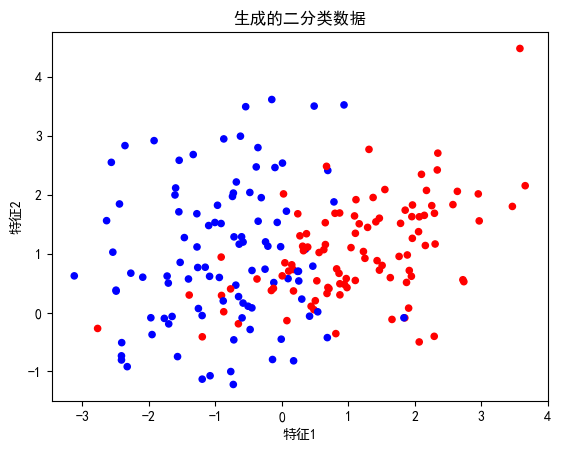

epoch0,loss=0.9355
epoch100,loss=0.3802
epoch200,loss=0.3690
epoch300,loss=0.3669
epoch400,loss=0.3663
epoch500,loss=0.3661
epoch600,loss=0.3660
epoch700,loss=0.3659
epoch800,loss=0.3659
epoch900,loss=0.3659

训练完成,theta=[ 0.21287553  1.94367116 -0.45321958]
sklearn 截距: 0.2194, 系数: [ 1.94724175 -0.4579085 ]


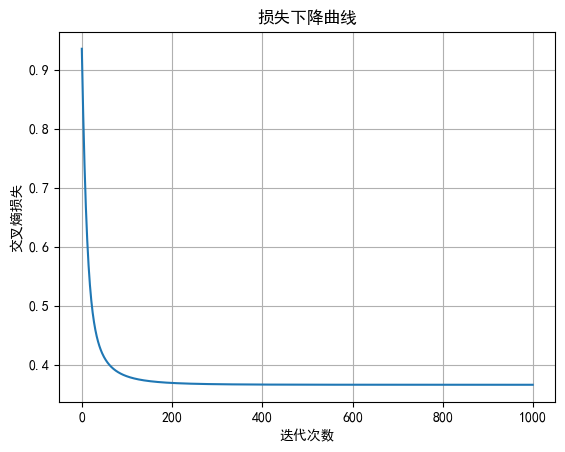

In [3]:
#交叉熵损失,手写逻辑回归
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
plt.rcParams['font.sans-serif'] = ['SimHei']        # 使用黑体
plt.rcParams['axes.unicode_minus'] = False          # 解决负号显示异常
#生成2分类数据,=
np.random.seed(42)
X,y=make_classification(n_samples=200,n_features=2,n_redundant=0,
                       n_clusters_per_class=1,random_state=42)
#n_samples 样本个数,样本特征个数2,冗余特征0，每个类簇的个数n_clusters_per_class,随机种子指定42

plt.scatter(X[:,0],X[:,1],c=y,cmap='bwr',s=20) 
#viridis黑黄,coolwarm 红蓝 bwr 红蓝对比度更大
#[[1,2],[3,4],[5,6]] 生成如此的二维数组,如果feature=3,一行三个
plt.xlabel('特征1')
plt.ylabel('特征2')
plt.title('生成的二分类数据')
plt.show()
#初始化参数

X_bias=np.c_[np.ones((X.shape[0],1)),X] #形状(200,3) 左边拼接200行1列的1

theta=np.random.randn(3,1) #初始化参数(3,1) 系数
lr=0.1 #学习率为0.1
epochs=1000 
m=len(X_bias) #200
#用于记录损失
loss_history=[]
def sigmoid(z):
    return 1/(1+np.exp(-z))
y = y.reshape(-1, 1) #变成(200,1)
#梯度下降
for epoch in range(epochs):
    z=X_bias @ theta #(200,1) 线性组合
    #预测概率
    y_pred=sigmoid(z)
    #交叉熵损失 L(y,p)=−[ylogp+(1−y)log(1−p)] 一个样本的交叉熵损失。
    loss=-np.mean(y*np.log(y_pred+1e-8)+(1-y)*np.log(1-y_pred+1e-8))
    loss_history.append(loss)
    #梯度
    dz=y_pred-y.reshape(-1,1)#(200,1)
    grad=(1/m)*X_bias.T.dot(dz) #(3,1)
    theta=theta-lr*grad
    if epoch %100==0 :
        print(f"epoch{epoch},loss={loss:.4f}")
print(f"\n训练完成,theta={theta.flatten()}")
#sklearn方式
#lr_sk=LogisticRegression()
lr_sk = LogisticRegression(penalty=None, solver='lbfgs')  # 无正则化
lr_sk.fit(X,y.ravel())#ravel压平
print(f"sklearn 截距: {lr_sk.intercept_[0]:.4f}, 系数: {lr_sk.coef_[0]}")

# 损失曲线
plt.plot(loss_history)
plt.xlabel('迭代次数')
plt.ylabel('交叉熵损失')
plt.title('损失下降曲线')
plt.grid(True)
plt.show()
#逻辑回归的决策边界 ≈ 线性回归的拟合直线，都是训练过程中逐渐趋近的一个线性方程。 区别在于前者用于分类，后者用于回归。

In [9]:
#解锁距离度量,手写knn分类器
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
#生成数据
np.random.seed(42)
X,y=make_classification(n_samples=10,n_features=4,n_informative=3,
                       n_redundant=1,random_state=42)#四个特征:三个有用,一个冗余
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
#0.2 表示测试集占20%,训练集占80%
print(f"字符串x:{X}\n")
print(X_train)
print(X_test)


字符串x:[[-0.21590467 -0.61404967  0.18038064 -0.73567609]
 [-0.04866114  1.10523166  3.60191909 -3.62574002]
 [-0.96475252 -1.34503796 -0.45832524 -0.31936956]
 [ 0.4279957   1.75384835  1.02768357  0.16247194]
 [ 2.33260149  0.77936651 -1.18998389  1.42617917]
 [ 0.64711149 -1.24261063 -0.47140592 -0.79941926]
 [-1.81656668  1.12047163  1.74040509 -0.53692372]
 [ 1.0563132   0.25879141  0.50295388 -0.79924156]
 [-0.710525    2.58671576  3.69210785 -2.09888048]
 [-0.69723348  1.43212223  2.27952584 -1.35649579]]

[[ 0.64711149 -1.24261063 -0.47140592 -0.79941926]
 [-0.21590467 -0.61404967  0.18038064 -0.73567609]
 [ 1.0563132   0.25879141  0.50295388 -0.79924156]
 [-0.96475252 -1.34503796 -0.45832524 -0.31936956]
 [-0.69723348  1.43212223  2.27952584 -1.35649579]
 [ 2.33260149  0.77936651 -1.18998389  1.42617917]
 [ 0.4279957   1.75384835  1.02768357  0.16247194]
 [-1.81656668  1.12047163  1.74040509 -0.53692372]]
[[-0.710525    2.58671576  3.69210785 -2.09888048]
 [-0.04866114  1.105231

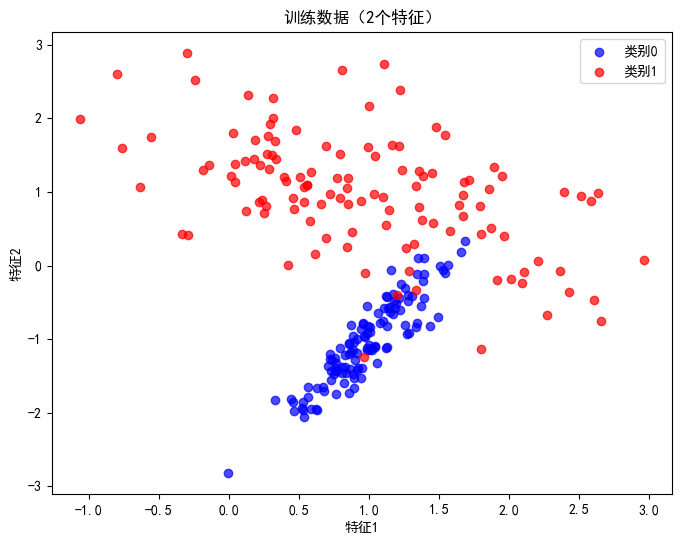

手写KNN准确率: 0.9500
sklearn KNN准确率: 0.9500
预测结果一致: True


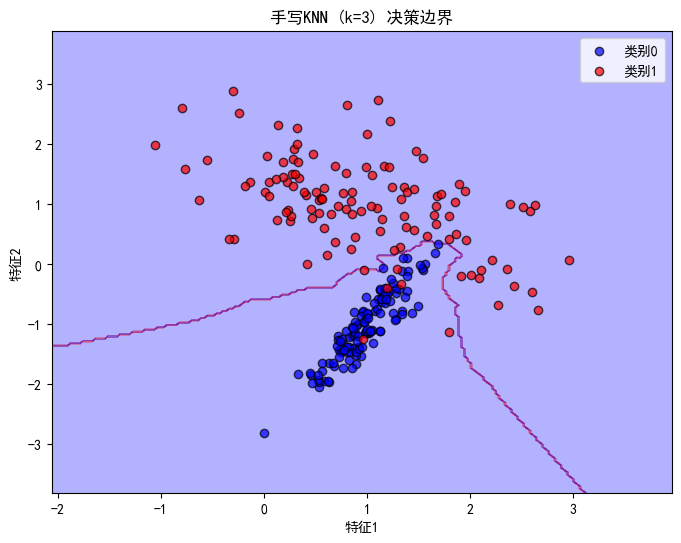

k= 1 | 训练准确率: 1.0000 | 测试准确率: 0.9167
k= 3 | 训练准确率: 0.9708 | 测试准确率: 0.9500
k= 5 | 训练准确率: 0.9708 | 测试准确率: 0.9500
k=10 | 训练准确率: 0.9667 | 测试准确率: 0.9500
k=20 | 训练准确率: 0.9583 | 测试准确率: 0.9500


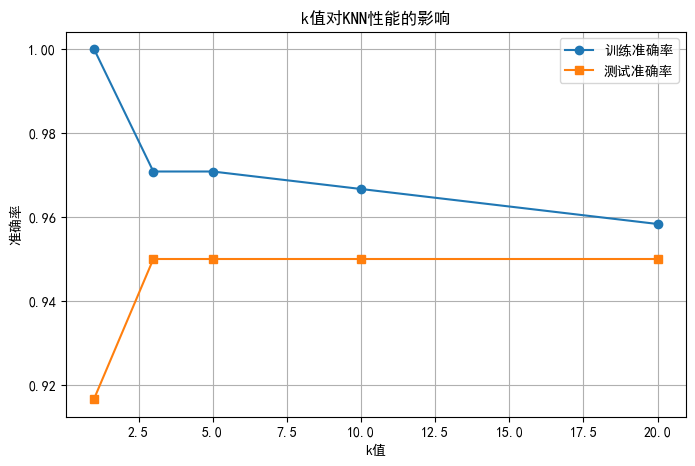

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# ==================== 1. 生成2个特征的分类数据 ====================
np.random.seed(42)
X, y = make_classification(n_samples=300, n_features=2, n_informative=2,
                           n_redundant=0, n_clusters_per_class=1, random_state=42)

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 可视化训练数据
plt.figure(figsize=(8, 6))
plt.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], c='blue', label='类别0', alpha=0.7)
plt.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], c='red', label='类别1', alpha=0.7)
plt.xlabel('特征1')
plt.ylabel('特征2')
plt.title('训练数据（2个特征）')
plt.legend()
plt.show()

# ==================== 2. 手写KNN分类器 ====================
class KNN:
    def __init__(self, k=3):
        self.k = k
    
    def fit(self, X_train, y_train):
        """保存训练数据"""
        self.X_train = X_train
        self.y_train = y_train
    
    def predict(self, X_test):
        """预测多个样本"""
        predictions = [self._predict(x) for x in X_test]
        return np.array(predictions)
    
    def _predict(self, x):
        """预测单个样本"""
        # 计算欧氏距离
        distances = np.sqrt(np.sum((self.X_train - x) ** 2, axis=1))
        
        # 取最近的k个索引
        k_indices = np.argsort(distances)[:self.k]
        
        # 取这k个样本的标签
        k_labels = self.y_train[k_indices]
        
        # 投票：返回出现次数最多的标签
        unique_labels, counts = np.unique(k_labels, return_counts=True)
        return unique_labels[np.argmax(counts)]

# ==================== 3. 训练手写KNN ====================
knn_manual = KNN(k=3)
knn_manual.fit(X_train, y_train)
y_pred_manual = knn_manual.predict(X_test)
acc_manual = accuracy_score(y_test, y_pred_manual)
print(f"手写KNN准确率: {acc_manual:.4f}")

# ==================== 4. 与sklearn对比 ====================
knn_sk = KNeighborsClassifier(n_neighbors=3)
knn_sk.fit(X_train, y_train)
y_pred_sk = knn_sk.predict(X_test)
acc_sk = accuracy_score(y_test, y_pred_sk)
print(f"sklearn KNN准确率: {acc_sk:.4f}")
print(f"预测结果一致: {np.array_equal(y_pred_manual, y_pred_sk)}")

# ==================== 5. 画决策边界 ====================
def plot_decision_boundary(knn_model, X, y, title):
    # 创建网格
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    
    # 预测网格点的类别
    Z = knn_model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # 画图
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, colors=['blue', 'red'])
    plt.scatter(X[y==0, 0], X[y==0, 1], c='blue', label='类别0', edgecolors='k', alpha=0.7)
    plt.scatter(X[y==1, 0], X[y==1, 1], c='red', label='类别1', edgecolors='k', alpha=0.7)
    plt.xlabel('特征1')
    plt.ylabel('特征2')
    plt.title(title)
    plt.legend()
    plt.show()

# 画手写KNN的决策边界
plot_decision_boundary(knn_manual, X_train, y_train, f'手写KNN (k={knn_manual.k}) 决策边界')

# ==================== 6. 不同k值效果对比 ====================
k_values = [1, 3, 5, 10, 20]
train_accs = []
test_accs = []

for k in k_values:
    knn = KNN(k=k)
    knn.fit(X_train, y_train)
    
    y_train_pred = knn.predict(X_train)
    y_test_pred = knn.predict(X_test)
    
    train_accs.append(accuracy_score(y_train, y_train_pred))
    test_accs.append(accuracy_score(y_test, y_test_pred))
    
    print(f"k={k:2d} | 训练准确率: {train_accs[-1]:.4f} | 测试准确率: {test_accs[-1]:.4f}")

# 画k值与准确率的关系图
plt.figure(figsize=(8, 5))
plt.plot(k_values, train_accs, 'o-', label='训练准确率')
plt.plot(k_values, test_accs, 's-', label='测试准确率')
plt.xlabel('k值')
plt.ylabel('准确率')
plt.title('k值对KNN性能的影响')
plt.legend()
plt.grid(True)
plt.show()

手写knn准确率:0.9500
sklearn knn准确率:0.9500
预测结果一致:True
Z 中的唯一值: [0 1]


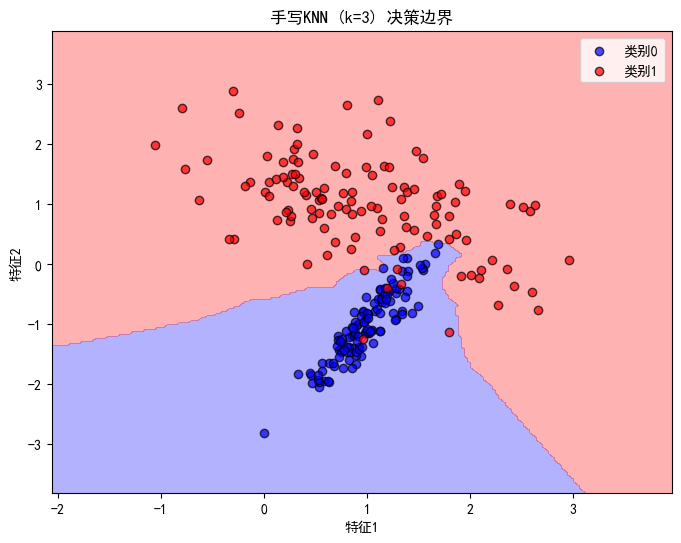

k= 1 | 训练准确率: 1.0000 | 测试准确率: 0.9167
k= 3 | 训练准确率: 0.9708 | 测试准确率: 0.9500
k= 5 | 训练准确率: 0.9708 | 测试准确率: 0.9500
k=10 | 训练准确率: 0.9667 | 测试准确率: 0.9500
k=20 | 训练准确率: 0.9583 | 测试准确率: 0.9500


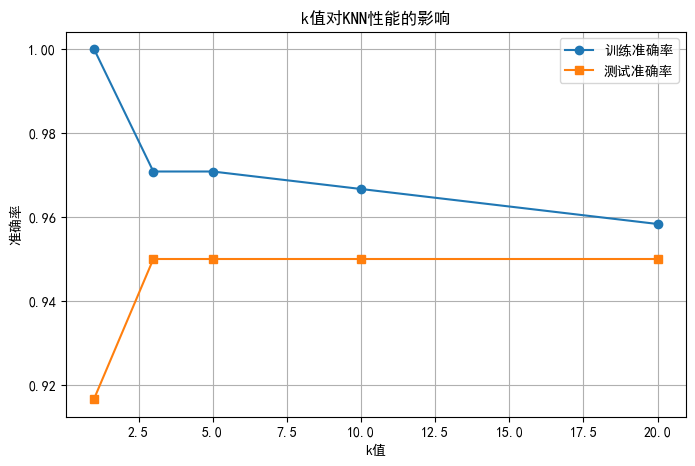

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 生成2个特征的分类数据
np.random.seed(42)
X, y = make_classification(n_samples=300, n_features=2, n_informative=2,
                           n_redundant=0, n_clusters_per_class=1, random_state=42)

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#knn 分类器
class KNN:
    def __init__(self, k=3):
        self.k=k #构造函数
    def fit(self,X_train,y_train): #保存训练数据
        self.X_train=X_train
        self.y_train=y_train
    def predict(self,X_test):#预测多个样本
        predictions=[self._predict(x) for x in X_test]
        return np.array(predictions)
    def _predict(self,x):#预测单个样本
        distances=np.sqrt(np.sum((self.X_train-x)**2,axis=1))#求的是每行的和
        k_indices=np.argsort(distances)[:self.k] #获取最近前k个样本索引。argsort排序获得索引
        k_labels=self.y_train[k_indices] #获取这k个样本的标签
        #投票:返回出现次数最多的标签
        unique_labels,counts=np.unique(k_labels,return_counts=True)#统计数组中每个唯一值出现的次数。
        return unique_labels[np.argmax(counts)]
        #举例：k=5，邻居标签为 [0, 1, 1, 1, 0].unique_labels = [0, 1]
        #counts = [2, 3]  np.argmax(counts) = 1（索引1对应标签1） 返回 1
knn_manual=KNN(k=3)
knn_manual.fit(X_train,y_train)
y_pred_manual=knn_manual.predict(X_test) #预测样本
acc_manual=accuracy_score(y_test,y_pred_manual)
print(f"手写knn准确率:{acc_manual:.4f}")
#与skleran对比
knn_sk=KNeighborsClassifier(n_neighbors=3)
knn_sk.fit(X_train,y_train)
y_pred_sk=knn_sk.predict(X_test)
acc_sk=accuracy_score(y_test,y_pred_manual)
print(f"sklearn knn准确率:{acc_sk:.4f}")
print(f"预测结果一致:{np.array_equal(y_pred_manual,y_pred_sk)}")

#画决策边界
def plot_decision_boundary(knn_model,X,y,title):
    x_min,x_max=X[:,0].min()-1,X[:,0].max()+1
    y_min,y_max=X[:,1].min()-1,X[:,1].max()+1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    #预测网格点的类别
    Z=knn_model.predict(np.c_[xx.ravel(),yy.ravel()])
    Z=Z.reshape(xx.shape)
    print("Z 中的唯一值:", np.unique(Z))
    # 画图
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5], colors=['blue', 'red'], alpha=0.3)
    #使用此函数区分颜色，可以填充整个块
    plt.scatter(X[y==0, 0], X[y==0, 1], c='blue', label='类别0', edgecolors='k', alpha=0.7)
    plt.scatter(X[y==1, 0], X[y==1, 1], c='red', label='类别1', edgecolors='k', alpha=0.7)
    plt.xlabel('特征1')
    plt.ylabel('特征2')
    plt.title(title)
    plt.legend()
    plt.show()
# 画手写KNN的决策边界
plot_decision_boundary(knn_manual, X_train, y_train, f'手写KNN (k={knn_manual.k}) 决策边界')

#不同k值效果对比
k_values = [1, 3, 5, 10, 20]
train_accs = []
test_accs = []

for k in k_values:
    knn = KNN(k=k)
    knn.fit(X_train, y_train)
    
    y_train_pred = knn.predict(X_train)
    y_test_pred = knn.predict(X_test)
    
    train_accs.append(accuracy_score(y_train, y_train_pred))
    test_accs.append(accuracy_score(y_test, y_test_pred))
    
    print(f"k={k:2d} | 训练准确率: {train_accs[-1]:.4f} | 测试准确率: {test_accs[-1]:.4f}")

# 画k值与准确率的关系图
plt.figure(figsize=(8, 5))
plt.plot(k_values, train_accs, 'o-', label='训练准确率')
plt.plot(k_values, test_accs, 's-', label='测试准确率')
plt.xlabel('k值')
plt.ylabel('准确率')
plt.title('k值对KNN性能的影响')
plt.legend()
plt.grid(True)
plt.show()